# Análise Exploratória do Dataset para Treinamento de RNA

## Avaliação de Qualidade dos Dados de Simulação de Sistema Elétrico

- `PLOAD_cenario`: carga ativa do cenário (MW)
- `PGWIND_disponivel_cenario`: geração eólica disponível no cenário (MW)
- `BESS_init_cenario`: estado inicial da bateria (MW)
- `CURTAILMENT_total_result`: total de corte de geração (MW)
- `BESS_operation_result`: operação da bateria (MW)



---


## 1. Importação das bibliotecas e definição da classe `RNADataAnalyzer`

In [3]:
from StationarityAnalyzer import RNADataAnalyzer

## 2. Carregamento dos dados e visão geral

In [4]:
# Caminho para o banco de dados
db_path = r'..\DATA\output_CLAGTEE_oficial\IEEE118_RNA_DATA_ACOPF_acoplado.db'

LINHAS_14B = ["4-7","4-9","5-6"]
LINHAS_1118B = [
    "8-5",      
    "26-25",    
    "30-17",    
    "38-37",    
    "63-59",    
    "64-61",   
    "65-66",    
    "81-80",    
    "68-69"
]

# Criar instância do analisador
analyzer = RNADataAnalyzer(
    db_path=db_path,
    load_linhas=True,
    linhas_especificas=LINHAS_1118B
)
# Visão geral
analyzer.overview()

Dados principais carregados. Registros: 3075552
Dados mesclados com linhas. Novo shape: (3075552, 26)
Total de registros: 3075552
Colunas disponíveis: ['id', 'cen_id', 'timestamp', 'data_simulacao', 'dia_semana', 'hora_simulacao', 'BAR_id', 'BAR_tipo', 'PLOAD_cenario', 'QLOAD_cenario', 'PGER_UTE_result', 'QGER_UTE_result', 'PLOSS_result', 'PDEF_result', 'PGWIND_disponivel_cenario', 'PGWIND_total_result', 'CURTAILMENT_total_result', 'BESS_init_cenario', 'BESS_operation_result', 'BESS_soc_atual_result', 'V_result', 'ANG_result', 'FLUX_result_65-66', 'FLUX_result_68-69', 'LIN_usage_result_65-66', 'LIN_usage_result_68-69']

Primeiras 5 linhas:
   id                cen_id                   timestamp data_simulacao  \
0   1  20260702192845_00000  2026-07-02T19:28:53.959479              1   
1   2  20260702192845_00000  2026-07-02T19:28:53.959479              1   
2   3  20260702192845_00000  2026-07-02T19:28:53.959479              1   
3   4  20260702192845_00000  2026-07-02T19:28:53.959479 

## 3. Estatísticas descritivas por hora



In [5]:
stats_hour = analyzer.get_hourly_stats()
display(stats_hour)

PLOAD_cenario                               \
                        mean     std  min     max   count   
hora_simulacao                                              
0                     0.2332  0.2579  0.0  2.0774  128148   
1                     0.2474  0.2734  0.0  2.1876  128148   
2                     0.2153  0.2390  0.0  1.9390  128148   
3                     0.2191  0.2434  0.0  1.9664  128148   
4                     0.2224  0.2465  0.0  1.9942  128148   
5                     0.2512  0.2780  0.0  2.2159  128148   
6                     0.2691  0.2970  0.0  2.3539  128148   
7                     0.2546  0.2813  0.0  2.2435  128148   
8                     0.2871  0.3174  0.0  2.4928  128148   
9                     0.3048  0.3367  0.0  2.6309  128148   
10                    0.3157  0.3484  0.0  2.7135  128148   
11                    0.3230  0.3568  0.0  2.7692  128148   
12                    0.3300  0.3643  0.0  2.8253  128148   
13                    0.3263  0.3598  0.0  2.7973  128148   
14                    0.3120  0.3446  0.0  2.6861  128148   
15                    0.3336  0.3683  0.0  2.8529  128148   
16                    0.3371  0.3717  0.0  2.8807  128148   
17                    0.3443  0.3798  0.0  2.9353  128148   
18                    0.3588  0.3955  0.0  3.0452  128148   
19                    0.3514  0.3871  0.0  2.9907  128148   
20                    0.3407  0.3757  0.0  2.9084  128148   
21                    0.3480  0.3837  0.0  2.9627  128148   
22                    0.2655  0.2934  0.0  2.3263  128148   
23                    0.1973  0.2190  0.0  1.8001  128148   

               PGWIND_disponivel_cenario                               ...  \
                                    mean     std  min     max   count  ...   
hora_simulacao                                                         ...   
0                                 0.0220  0.1652  0.0  2.8278  128148  ...   
1                                 0.0206  0.1534  0.0  3.0000  128148  ...   
2                                 0.0205  0.1543  0.0  3.0000  128148  ...   
3                                 0.0205  0.1558  0.0  2.8300  128148  ...   
4                                 0.0197  0.1513  0.0  2.8329  128148  ...   
5                                 0.0195  0.1482  0.0  2.8241  128148  ...   
6                                 0.0196  0.1510  0.0  2.8960  128148  ...   
7                                 0.0194  0.1515  0.0  2.9735  128148  ...   
8                                 0.0186  0.1468  0.0  3.0000  128148  ...   
9                                 0.0171  0.1433  0.0  3.0000  128148  ...   
10                                0.0172  0.1449  0.0  3.0000  128148  ...   
11                                0.0182  0.1537  0.0  3.0000  128148  ...   
12                                0.0191  0.1562  0.0  3.0000  128148  ...   
13                                0.0190  0.1551  0.0  3.0000  128148  ...   
14                                0.0200  0.1624  0.0  3.0000  128148  ...   
15                                0.0209  0.1700  0.0  3.0000  128148  ...   
16                                0.0204  0.1629  0.0  3.0000  128148  ...   
17                                0.0210  0.1654  0.0  2.8190  128148  ...   
18                                0.0207  0.1628  0.0  2.8825  128148  ...   
19                                0.0204  0.1590  0.0  2.9462  128148  ...   
20                                0.0212  0.1641  0.0  2.9200  128148  ...   
21                                0.0213  0.1637  0.0  2.9263  128148  ...   
22                                0.0220  0.1660  0.0  2.8435  128148  ...   
23                                0.0219  0.1637  0.0  2.8248  128148  ...   

               PGER_UTE_result                              QGER_UTE_result  \
                          mean     std  min     max   count            mean   
hora_simulacao                                                                
0                      

In [6]:
stats_by_bar = analyzer.get_hourly_stats_by_bar()
print(stats_by_bar.head())

                      PLOAD_cenario                                \
                               mean     std     min     max count   
BAR_id hora_simulacao                                               
1      0                     0.3330  0.0296  0.2806  0.3823  1086   
       1                     0.3507  0.0290  0.3009  0.4027  1086   
       2                     0.3062  0.0292  0.2553  0.3570  1086   
       3                     0.3123  0.0301  0.2602  0.3621  1086   
       4                     0.3162  0.0294  0.2654  0.3671  1086   

                      PGWIND_disponivel_cenario                       ...  \
                                           mean  std  min  max count  ...   
BAR_id hora_simulacao                                                 ...   
1      0                                    0.0  0.0  0.0  0.0  1086  ...   
       1                                    0.0  0.0  0.0  0.0  1086  ...   
       2                                    0.0  0.0  0.0  0.0

## 4. Perfil horário médio

Os gráficos abaixo mostram a média e a banda de ±1 desvio padrão para cada variável ao longo das horas do dia. A análise visual permite detectar:
- **Padrões diários**: por exemplo, a carga (`PLOAD_cenario`) geralmente apresenta picos durante o dia e vales à noite.
- **Variabilidade**: desvios grandes indicam maior dispersão dos dados naquela hora.
- **Comportamento esperado**: verificar se os perfis estão de acordo com o conhecimento do sistema (ex.: geração eólica tende a ser mais alta em certas horas).

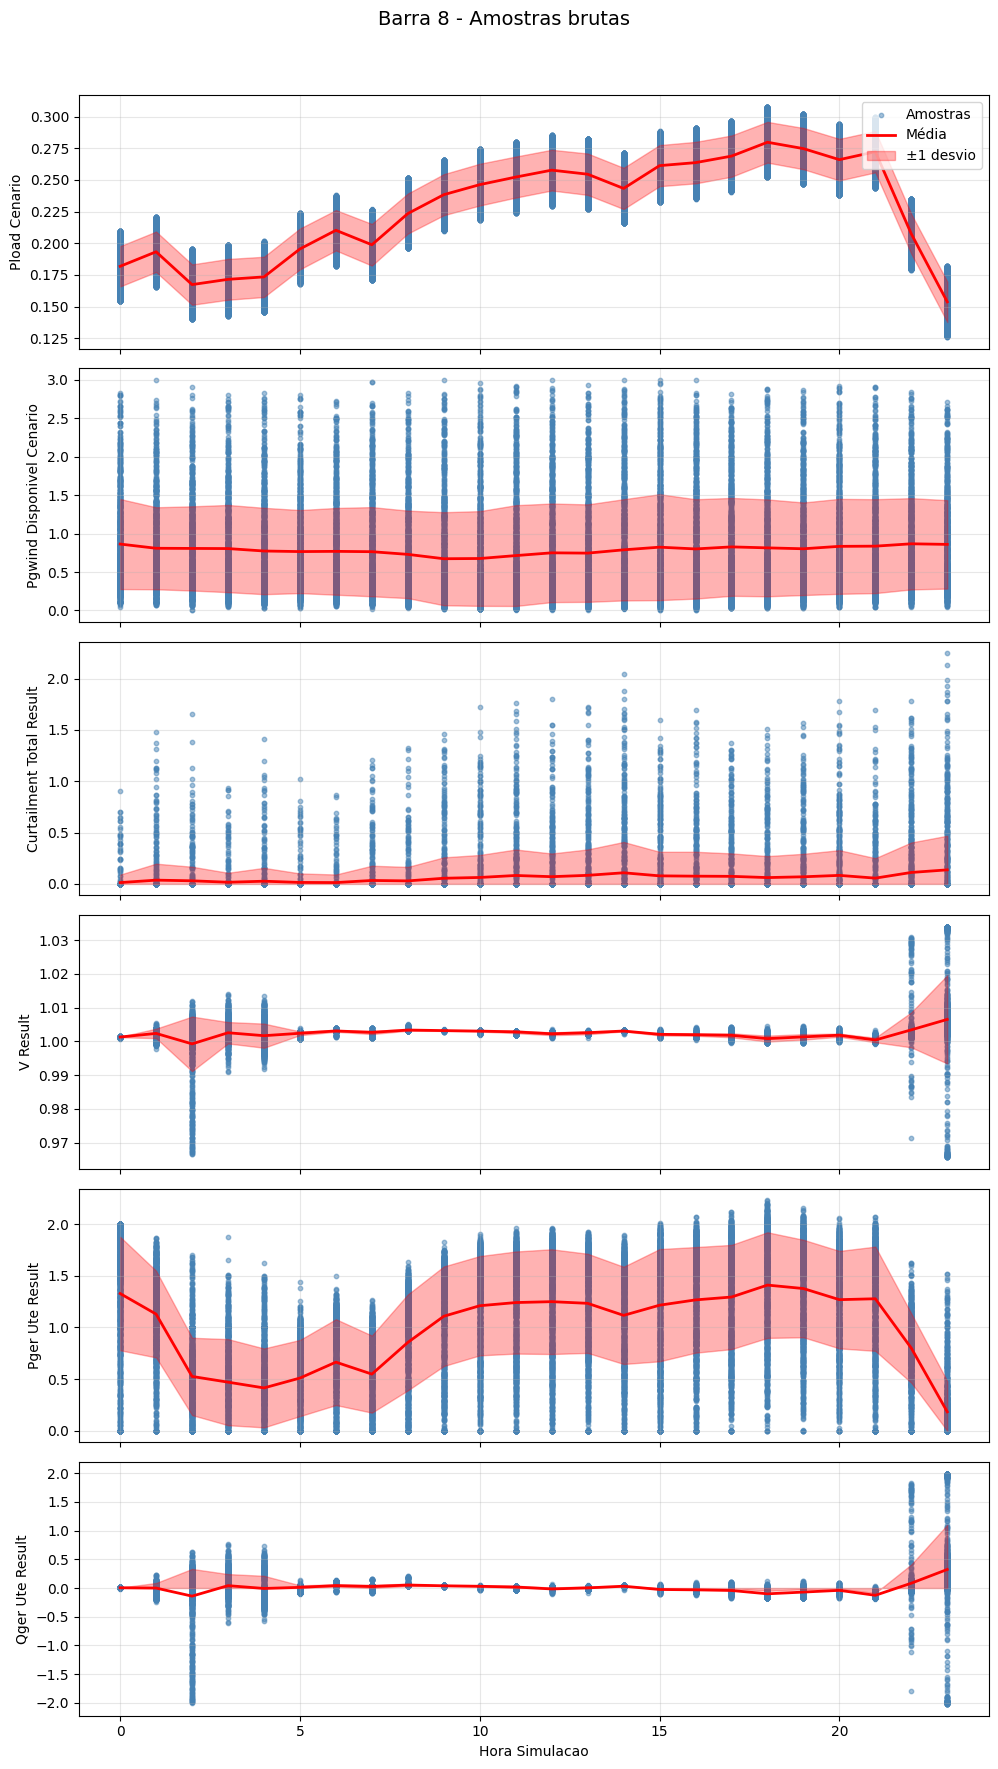

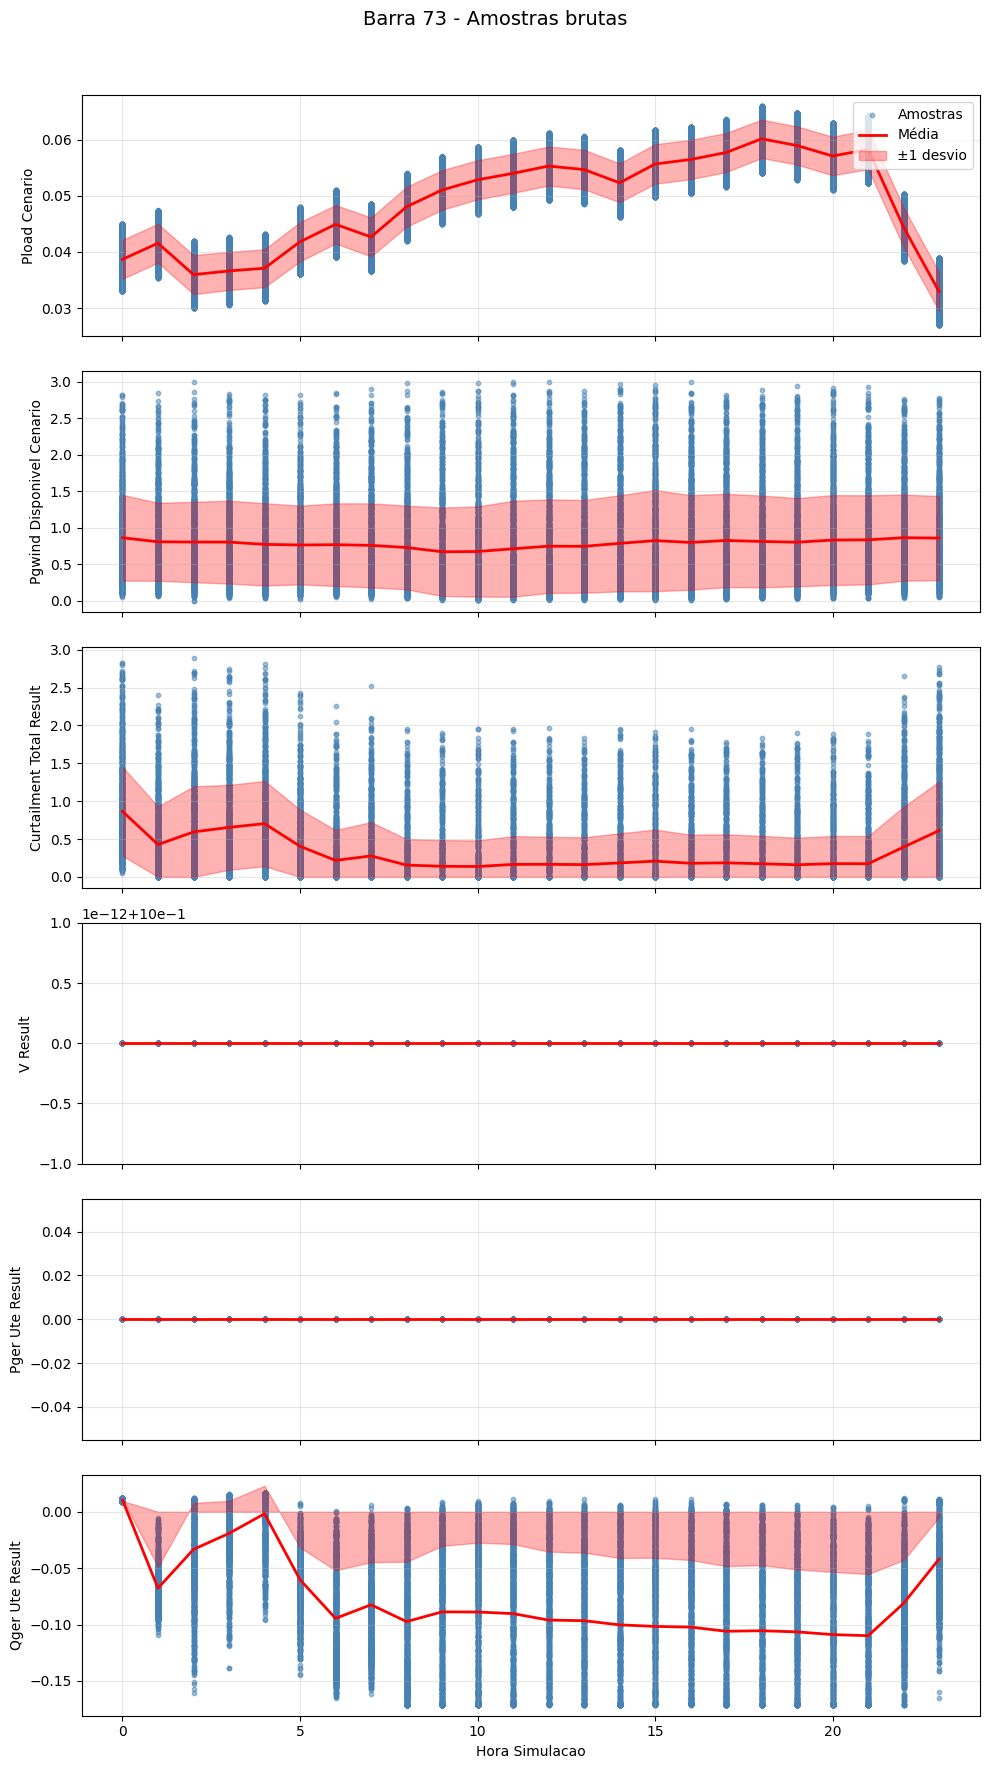

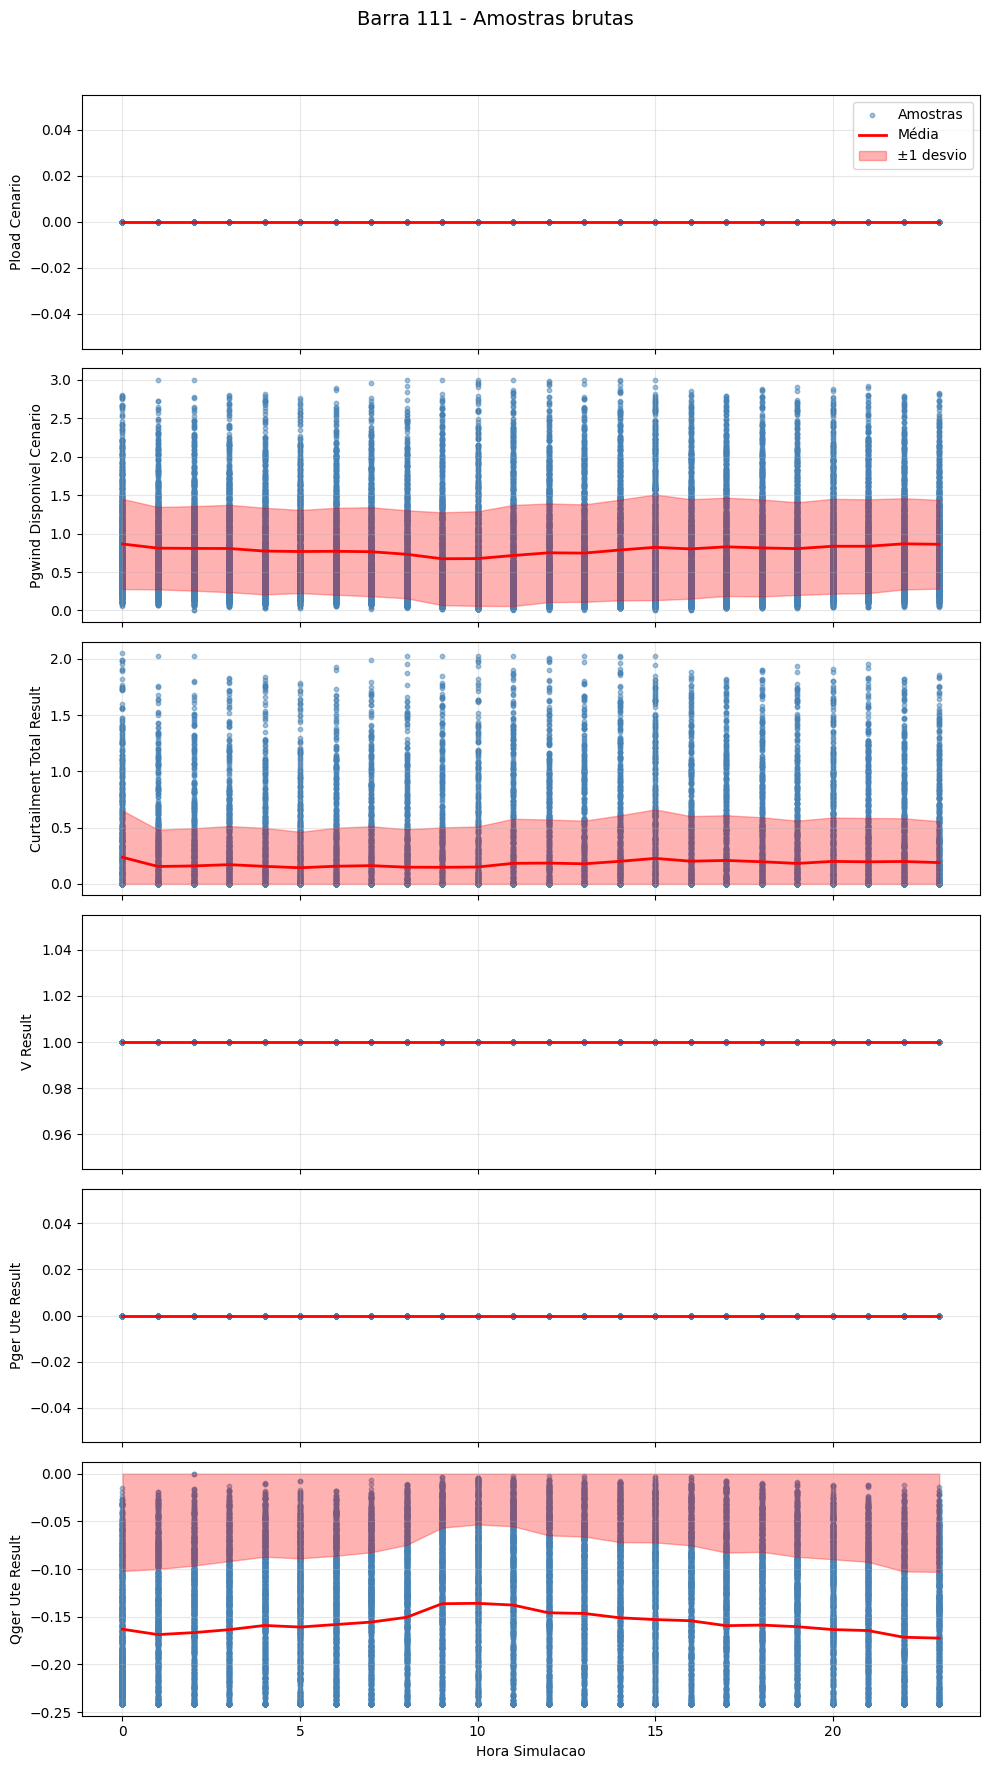

In [7]:
#analyzer.plot_raw_samples_by_bar(bar_ids=[2, 3, 4, 6, 9, 14] , show_mean_std=True)
analyzer.plot_raw_samples_by_bar(bar_ids=[8,73,111] , show_mean_std=True)

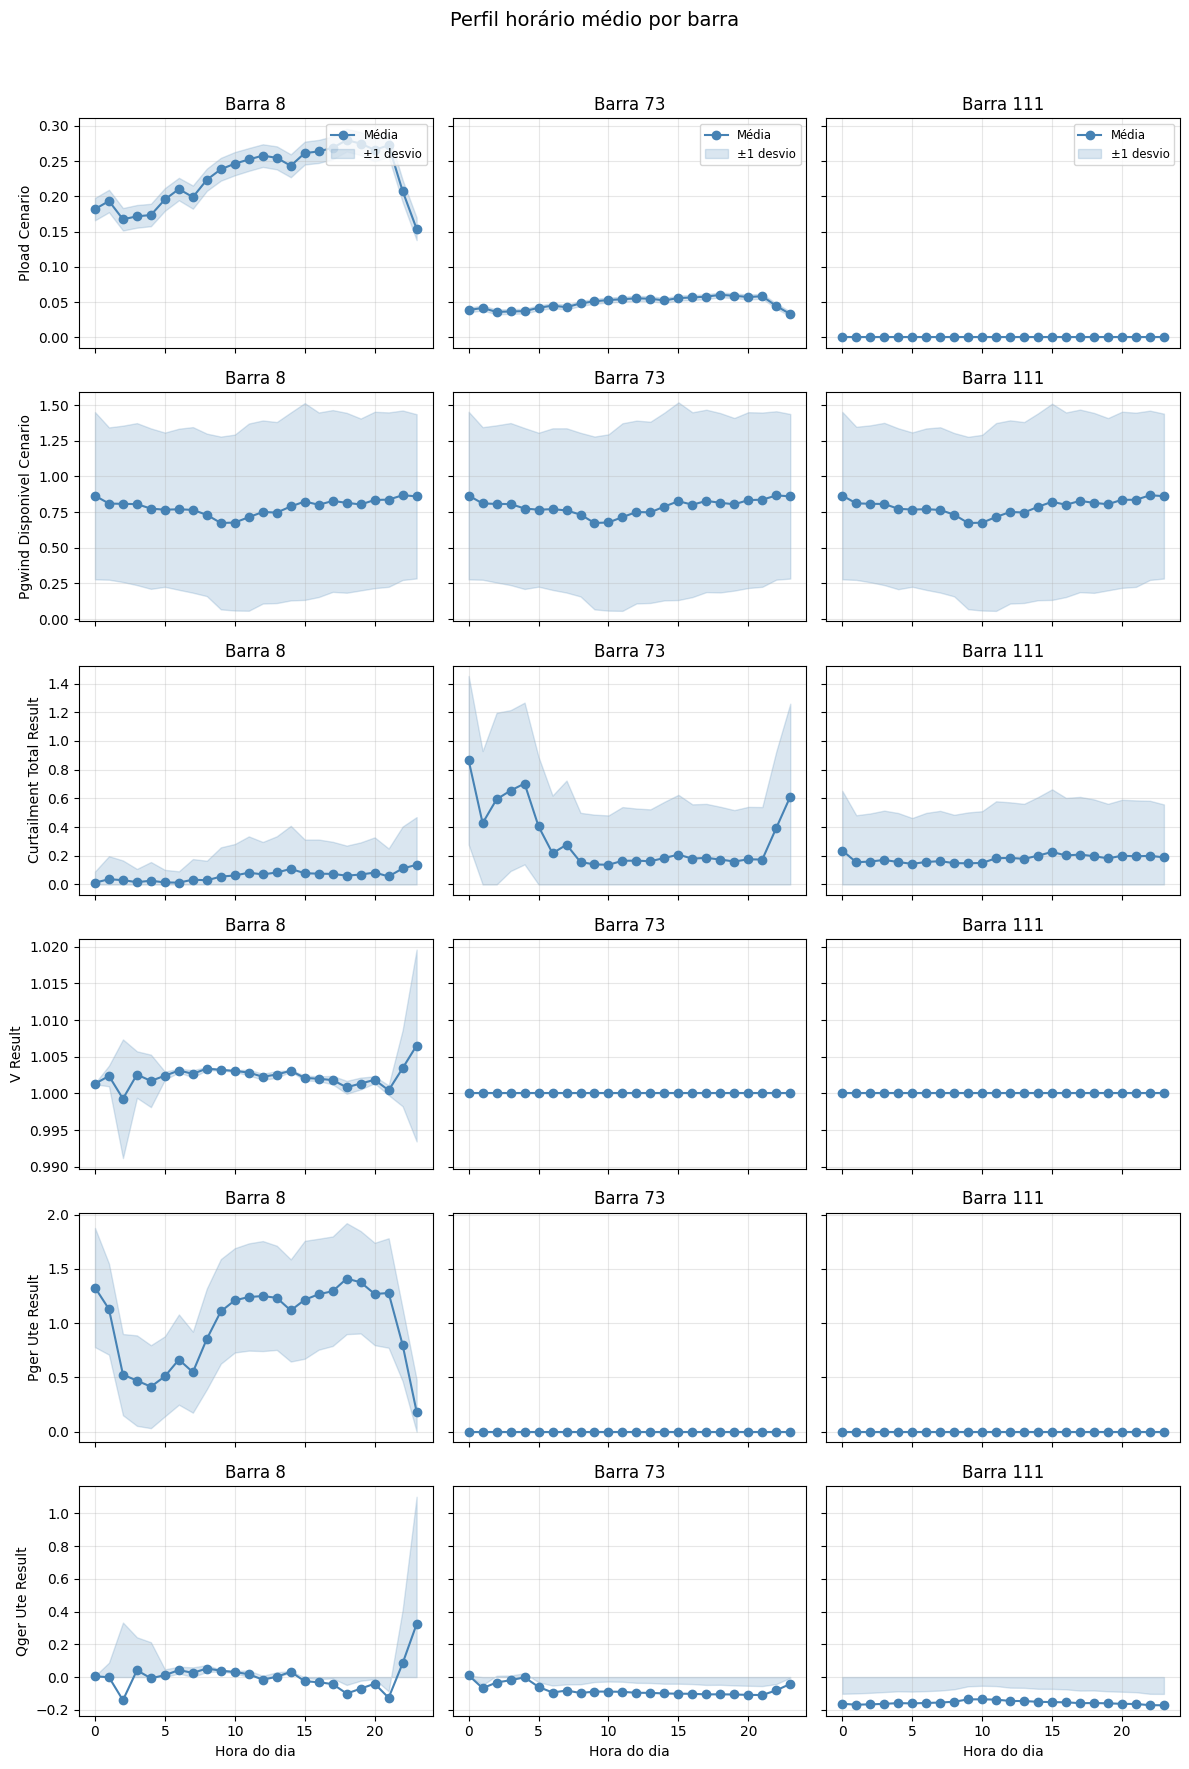

In [8]:
# Plotar perfis para todas as barras
analyzer.get_hourly_stats_by_bar(bar_ids=[8,73,111] )
analyzer.plot_hourly_profiles_by_bar(bar_ids=[8,73,111])

## 5. Matriz de correlação

A correlação entre as variáveis pode revelar relações lineares importantes. Por exemplo:
- Se `CURTAILMENT_total_result` estiver fortemente correlacionado com `PGWIND_disponivel_cenario`, faz sentido, pois o corte de geração eólica ocorre quando há excesso de vento.
- Se houver correlações inesperadas (ex.: `BESS_operation_result` fortemente correlacionado com `PLOAD_cenario`), pode indicar dependências que devem ser capturadas pelo modelo.

A matriz também ajuda a verificar multicolinearidade, que pode afetar o treinamento da rede neural.

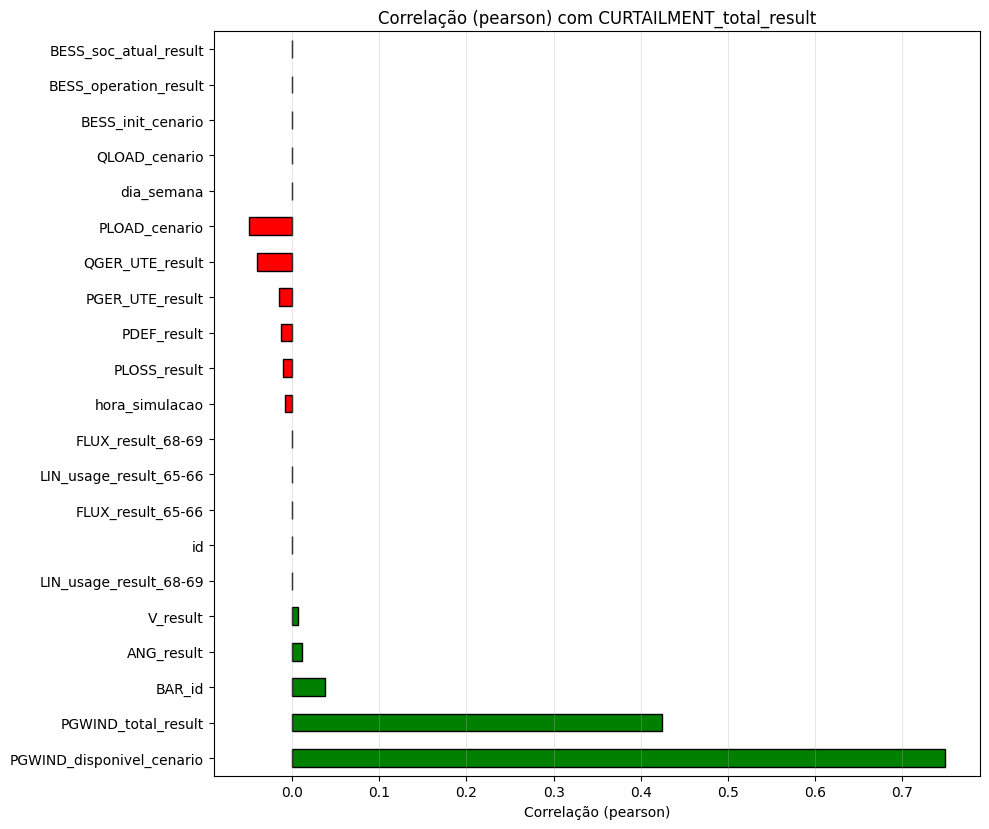

In [9]:
corr = analyzer.feature_target_correlation(target='CURTAILMENT_total_result', plot=True)

## 7. Estatísticas descritivas globais

Além da análise por hora, é útil ter uma visão geral das variáveis: média, desvio padrão, assimetria e curtose. Assimetria positiva indica cauda à direita (valores altos raros), enquanto curtose alta sugere a presença de outliers.

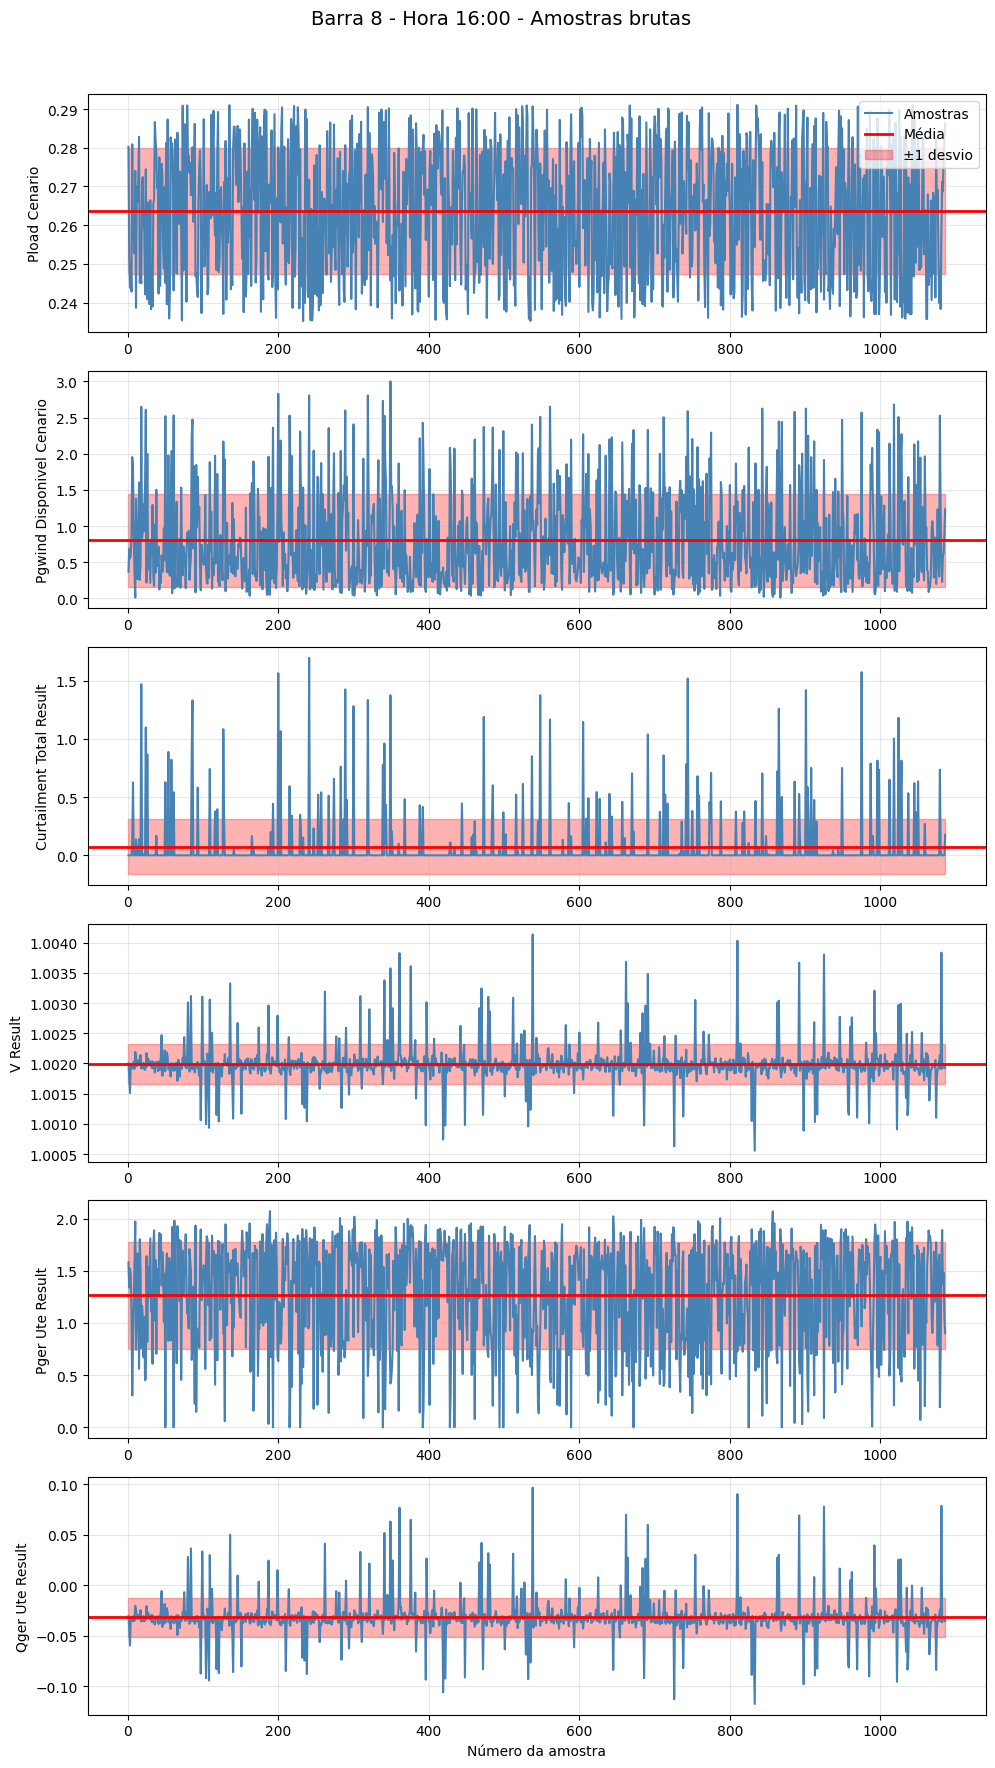

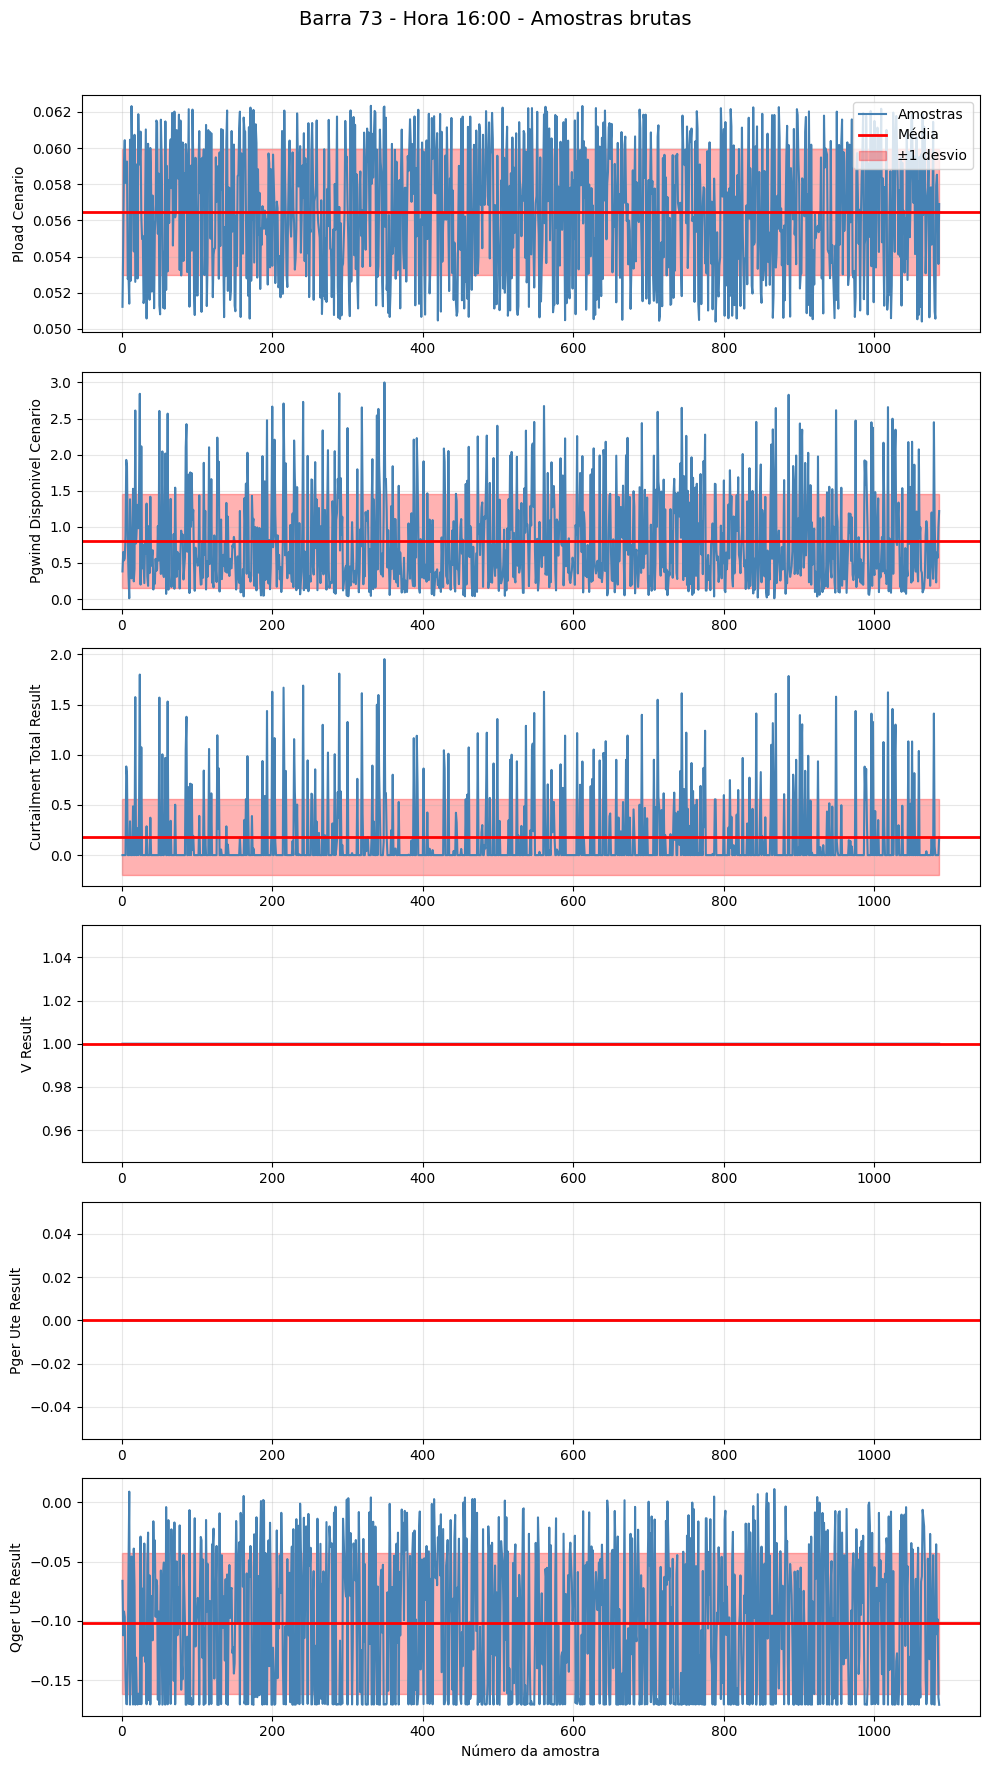

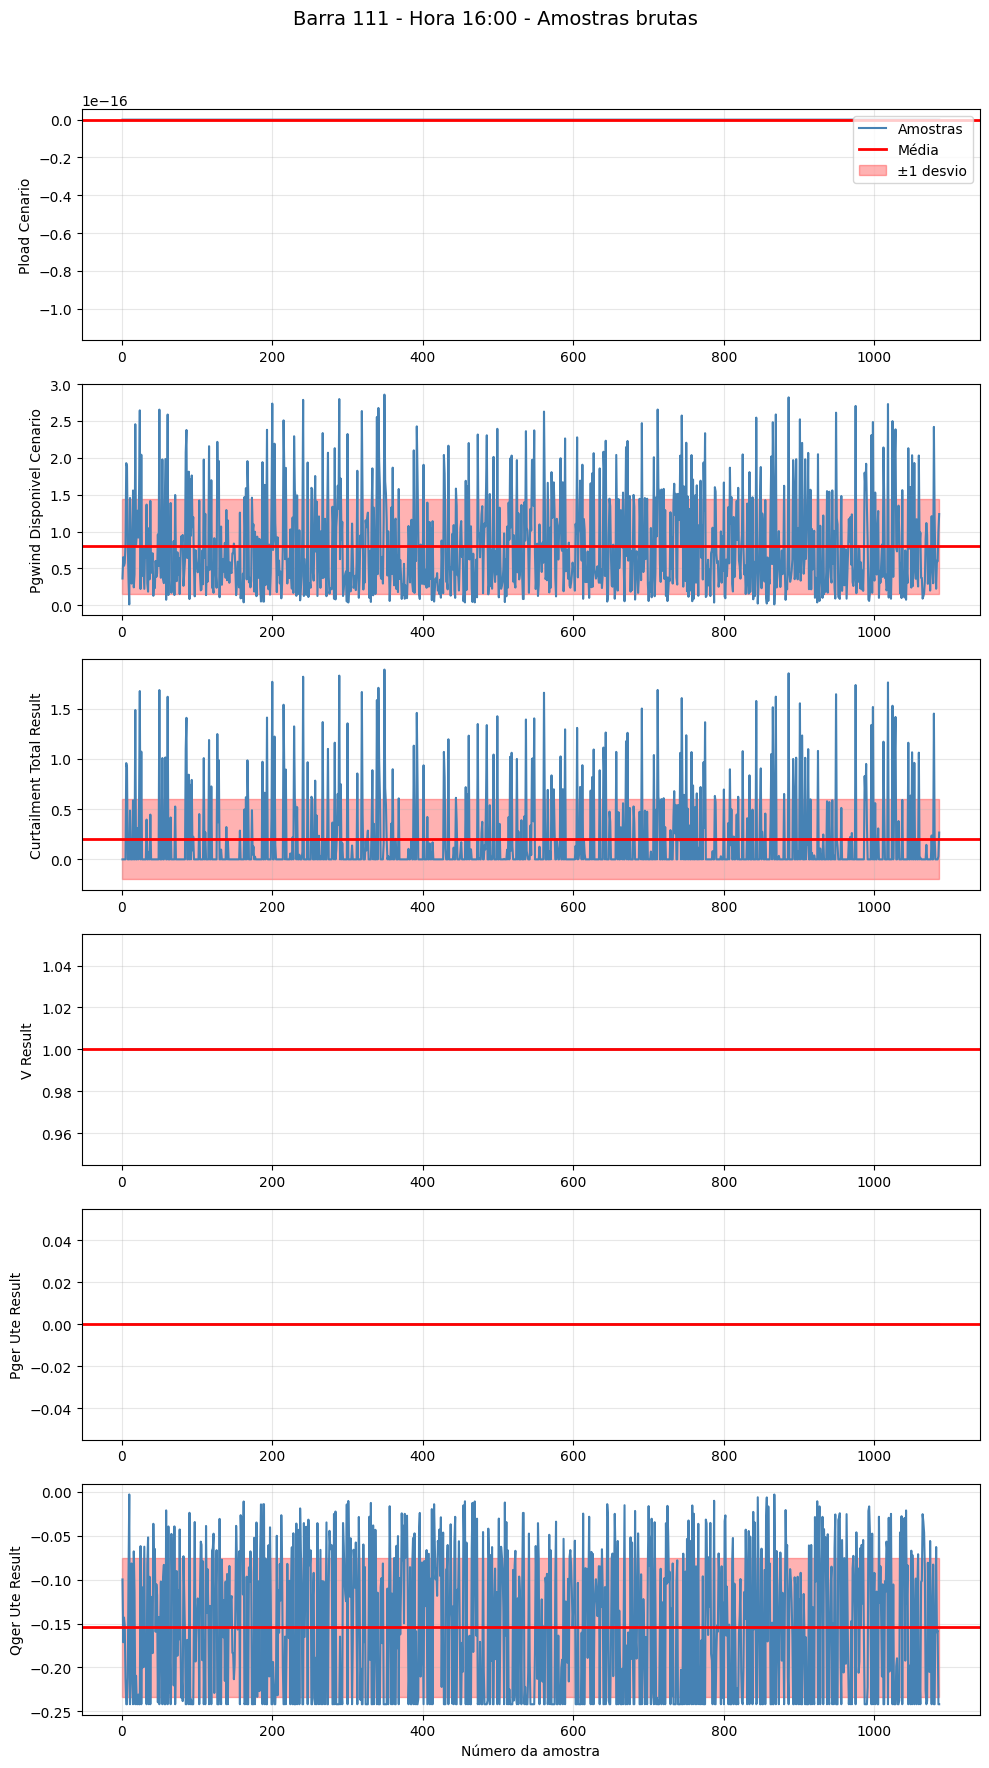

In [10]:
analyzer.plot_samples_at_hour(hour=16, bar_ids=[8,73,111]  , show_mean_std=True)

In [11]:
desc_stats = analyzer.descriptive_statistics()
display(desc_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
PLOAD_cenario,3075552.0,0.291155,0.329956,0.000000,0.084826,0.206367,0.397411,3.045221,3.007452,14.185143
PGWIND_disponivel_cenario,3075552.0,0.020037,0.157286,0.000000,0.000000,0.000000,0.000000,3.000000,10.135069,118.356877
CURTAILMENT_total_result,3075552.0,0.004688,0.068922,0.000000,0.000000,0.000000,0.000000,2.892204,18.808724,412.943296
V_result,3075552.0,0.999149,0.010876,0.950000,0.997947,1.000000,1.000383,1.050000,-1.540306,7.971757
PGER_UTE_result,3075552.0,0.250933,0.905589,0.000000,0.000000,0.000000,0.000000,7.745009,4.760513,26.117666
QGER_UTE_result,3075552.0,0.025456,0.242212,-2.024367,0.000000,0.000000,0.048221,1.992401,-0.427954,10.866468
